# NBA final point difference — margin of victory

How lopsided do NBA games end up? Each game finishes with some point
difference (the margin of victory), and here we look at the distribution of
that margin across whole seasons.

Data comes from NBA.com via `nba_api`'s `LeagueGameLog` endpoint — the
league-wide analogue of the per-player game logs used elsewhere in this
project — cached locally under `data/cache/`. Each game's final margin is the
absolute value of a team's `PLUS_MINUS`; `get_game_margins` collapses the two
team rows per game into one row with a `MARGIN` column.

Season convention: the ending year — `2026` = the 2025-26 season.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from nba_analysis.data import get_game_margins

sns.set_theme(style="whitegrid")

# Two categorical colors (dataviz slots 1 and 6), well separated for CVD.
C_ONE = "#2a78d6"    # this past season
C_THREE = "#eb6834"  # past three seasons

## Load the margins

`this_season` is 2025-26 alone; `three_seasons` pools 2023-24, 2024-25, and
2025-26. Each season is a full 1230-game regular season.

In [2]:
this_season = get_game_margins(2026)
three_seasons = get_game_margins([2024, 2025, 2026])

print(f"this season:   {len(this_season):>4} games, "
      f"mean margin {this_season['MARGIN'].mean():.1f}, max {this_season['MARGIN'].max()}")
print(f"three seasons: {len(three_seasons):>4} games, "
      f"mean margin {three_seasons['MARGIN'].mean():.1f}, max {three_seasons['MARGIN'].max()}")

this season:   1230 games, mean margin 13.3, max 55
three seasons: 3690 games, mean margin 12.9, max 62


## Histogram — this past season (2025-26)

One bin per point of margin. NBA games can't end tied, so the distribution
starts at 1. It rises to a mode around a 5–9 point margin and then decays
through a long right tail of blowouts.

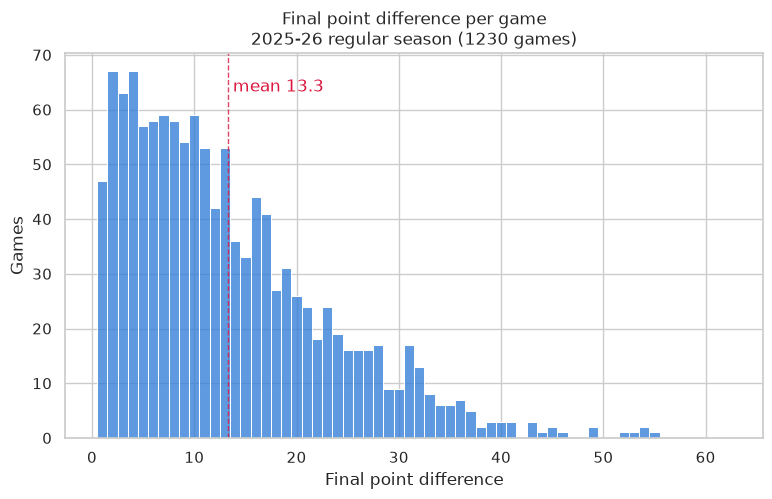

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

bins = np.arange(0.5, three_seasons['MARGIN'].max() + 1.5)
sns.histplot(this_season, x='MARGIN', bins=bins, color=C_ONE,
             edgecolor='white', ax=ax)

mean_val = this_season['MARGIN'].mean()
ax.axvline(mean_val, color='crimson', linestyle='--', linewidth=1, alpha=0.8)
ax.text(mean_val + 0.5, ax.get_ylim()[1] * 0.9, f'mean {mean_val:.1f}',
        color='crimson')

ax.set_title('Final point difference per game\n2025-26 regular season '
             f'({len(this_season)} games)')
ax.set_xlabel('Final point difference')
ax.set_ylabel('Games')
plt.show()

## Histogram — past three seasons (2023-24 through 2025-26)

Same shape, three times the games, so the tail fills in more smoothly.

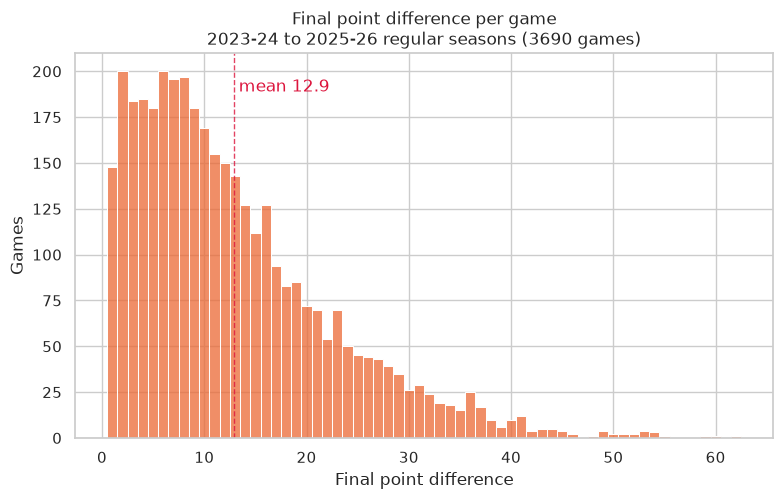

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(three_seasons, x='MARGIN', bins=bins, color=C_THREE,
             edgecolor='white', ax=ax)

mean_val = three_seasons['MARGIN'].mean()
ax.axvline(mean_val, color='crimson', linestyle='--', linewidth=1, alpha=0.8)
ax.text(mean_val + 0.5, ax.get_ylim()[1] * 0.9, f'mean {mean_val:.1f}',
        color='crimson')

ax.set_title('Final point difference per game\n2023-24 to 2025-26 regular seasons '
             f'({len(three_seasons)} games)')
ax.set_xlabel('Final point difference')
ax.set_ylabel('Games')
plt.show()

## Counts per margin

For the log-scaled plots below we need the raw frequency — the number of
games at each exact margin — for both datasets on a shared integer grid.

Note the two series are on different totals: the three-season pool has ~3×
the games of the single season, so it naturally sits higher. The instruction
was to use the raw number of games as the frequency, so these are counts, not
densities — the single season and three-season curves are the same shape
offset vertically by roughly a factor of three.

In [5]:
def margin_counts(df, max_margin):
    """Number of games at each integer margin from 1..max_margin."""
    grid = np.arange(1, max_margin + 1)
    counts = df['MARGIN'].value_counts().reindex(grid, fill_value=0)
    return grid, counts.to_numpy()

max_margin = three_seasons['MARGIN'].max()
x1, y1 = margin_counts(this_season, max_margin)
x3, y3 = margin_counts(three_seasons, max_margin)

## Log-log plot

Point difference and number of games both on log axes. Zero-count margins in
the far tail are dropped (a log axis has no room for them). A straight line
here would mean a power law; the visible downward curvature says the tail
falls off faster than any power law — consistent with the roughly
exponential decay that shows up as a straight line on the semi-log plot next.

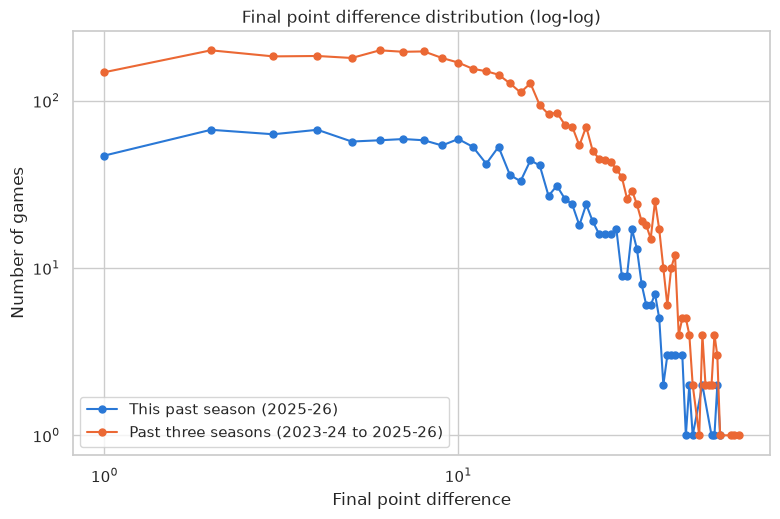

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for x, y, color, label in [
    (x1, y1, C_ONE, 'This past season (2025-26)'),
    (x3, y3, C_THREE, 'Past three seasons (2023-24 to 2025-26)'),
]:
    nz = y > 0  # log axes can't show zero counts
    ax.plot(x[nz], y[nz], marker='o', markersize=5, linewidth=1.5,
            color=color, label=label)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Final point difference distribution (log-log)')
ax.set_xlabel('Final point difference')
ax.set_ylabel('Number of games')
ax.legend()
plt.show()

## Semi-log plot

Point difference on a linear axis, number of games on a log axis. Across the
bulk of the range each series is close to a straight line, which is the
signature of exponential decay: the chance of a game ending at margin *m*
falls by a roughly constant factor for each additional point. The two lines
run parallel, offset by the ~3× difference in total games.

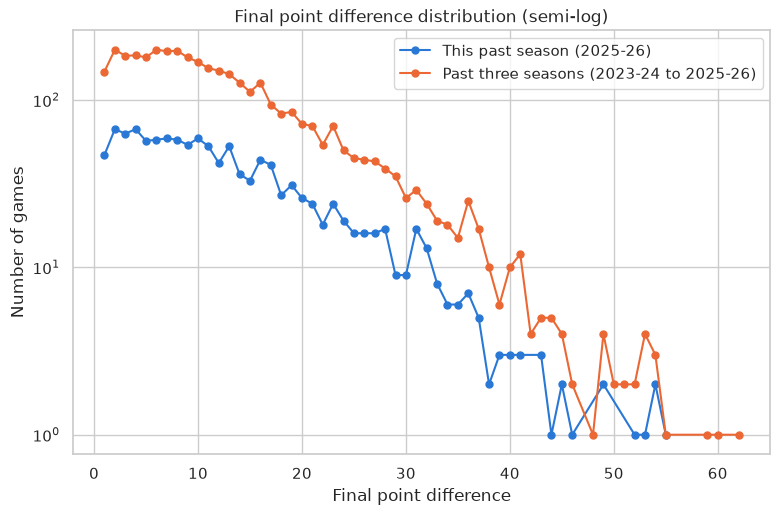

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for x, y, color, label in [
    (x1, y1, C_ONE, 'This past season (2025-26)'),
    (x3, y3, C_THREE, 'Past three seasons (2023-24 to 2025-26)'),
]:
    nz = y > 0
    ax.plot(x[nz], y[nz], marker='o', markersize=5, linewidth=1.5,
            color=color, label=label)

ax.set_yscale('log')
ax.set_title('Final point difference distribution (semi-log)')
ax.set_xlabel('Final point difference')
ax.set_ylabel('Number of games')
ax.legend()
plt.show()